<a href="https://colab.research.google.com/github/chuy-zip/COMPUTER_VISION_LAB10/blob/main/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Evolución del Espacio Latente en Stable Diffusion
### Integrantes:

* Sergio Orellana 221122
* Rodrigo Mansilla 22611
* Ricardo Chuy 221007


## Instalación de dependencias
- diffusers: contiene StableDiffusionPipeline, el VAE, el Scheduler y la U-Net
- transformers: provee el encoder de texto CLIP que convierte el prompt en embeddings
- accelerate: optimiza la carga y distribución del modelo en GPU
- torch: framework de tensores sobre el que corre todo el proceso

In [ ]:
%pip install -q diffusers transformers accelerate torchvision

In [2]:
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.



## Paso 1: Instanciar el modelo y enviarlo a la GPU

StableDiffusionPipeline.from_pretrained() descarga los pesos desde Hugging Face (~4 GB la primera vez) y los cachea localmente.

- `torch_dtype=torch.float16`: carga el modelo en precisión FP16 en lugar de FP32. Reduce el uso de VRAM a la mitad con pérdida de calidad mínima — necesario para caber en la GPU T4 de Colab (15 GB VRAM).
- `.to("cuda")`: mueve todos los componentes del pipeline a la GPU: U-Net, VAE y el encoder de texto CLIP.

In [3]:
pipe = StableDiffusionPipeline.from_pretrained(
    "sd-legacy/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")
print("Modelo cargado en:", next(pipe.unet.parameters()).device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado en: cuda:0



## Paso 2: Definir 20 pasos de inferencia y fijar la semilla aleatoria

- `torch.manual_seed(42)`: fija el generador de números aleatorios. Esto garantiza que el **ruido inicial** del que parte el proceso sea siempre el mismo — sin esto, cada ejecución produce una imagen diferente.
- `num_inference_steps = 20`: el scheduler dividirá el proceso de denoising en exactamente 20 pasos, como pide el enunciado.

In [4]:
torch.manual_seed(42)
num_inference_steps = 20
print(f"Semilla fijada. Pasos de inferencia: {num_inference_steps}")

Semilla fijada. Pasos de inferencia: 20



## Paso 3: Definir el prompt

Prompt diseñado para forzar al modelo a generar estructuras geométricas complejas (fruta futurista) y texturas de alta frecuencia (luces neón, detalles 4k), lo que hace más evidente la diferencia entre los pasos iniciales y finales del denoising.

In [5]:
prompt = "A highly detailed cinematic and futuristic fruit glowing in a cyberpunk laboratory, neon lights, 4k resolution"
print("Prompt:", prompt)

Prompt: A highly detailed cinematic and futuristic fruit glowing in a cyberpunk laboratory, neon lights, 4k resolution



## Pasos 4 y 5: Interceptar el tensor latente en los pasos 4, 10, 16 y 20


### ¿Qué es el tensor latente?
Stable Diffusion no trabaja directamente en píxeles. El VAE encoder comprime la imagen a un espacio latente 8× más pequeño. Una imagen de 512×512 px tiene un tensor latente de forma `(1, 4, 64, 64)` 4 canales de 64×64. La U-Net elimina el ruido en ese espacio comprimido paso a paso.

### Estrategia elegida: `callback_on_step_end`
El enunciado da dos opciones (hint): usar `callback_on_step_end` o escribir el loop manualmente con `scheduler.step()`. Usamos el callback porque es más limpio y no requiere reescribir el pipeline entero.

La función `callback_on_step_end` es llamada automáticamente por el pipeline **al terminar cada paso**. Recibe `step_index` (0-indexado), por lo que el paso 4 llega como índice 3, el 10 como 9, etc.

**`.clone()` es importante:** sin él guardaríamos una referencia al mismo tensor que el pipeline sigue modificando. Al final todos los tensores guardados serían iguales al del paso 20.

In [6]:
capture_steps = {4, 10, 16, 20}
saved_latents = {}

def callback_on_step_end(pipe, step_index, timestep, callback_kwargs):
    current_step = step_index + 1  # step_index es 0-indexado
    if current_step in capture_steps:
        saved_latents[current_step] = callback_kwargs["latents"].clone()
        print(f"  [Paso {current_step}] Tensor capturado | shape: {saved_latents[current_step].shape}")
    return callback_kwargs

print("Iniciando denoising...")
result = pipe(
    prompt,
    num_inference_steps=num_inference_steps,
    callback_on_step_end=callback_on_step_end,
    callback_on_step_end_tensor_inputs=["latents"]
)

final_image = result.images[0]
print(f"\nDenoising completo. Tensores guardados en pasos: {sorted(saved_latents.keys())}")

Iniciando denoising...


  0%|          | 0/20 [00:00<?, ?it/s]

  [Paso 4] Tensor capturado | shape: torch.Size([1, 4, 64, 64])
  [Paso 10] Tensor capturado | shape: torch.Size([1, 4, 64, 64])
  [Paso 16] Tensor capturado | shape: torch.Size([1, 4, 64, 64])
  [Paso 20] Tensor capturado | shape: torch.Size([1, 4, 64, 64])

Denoising completo. Tensores guardados en pasos: [4, 10, 16, 20]



## Paso 6: Decodificar los 4 tensores latentes con `vae.decode()`

### ¿Por qué dividir por `scaling_factor`?
El pipeline de Stable Diffusion escala matemáticamente los tensores latentes antes de trabajar con ellos: multiplica cada latente por `scaling_factor` (~0.18215) para normalizar la varianza. Cuando guardamos el tensor desde el callback, lo obtenemos ya escalado. El VAE decoder fue entrenado esperando tensores en su escala original (sin ese factor). Si le pasamos el tensor escalado directamente, el decoder recibe valores fuera de su rango esperado -> imágenes completamente negras.

Solución: dividir por scaling_factor antes de vae.decode().

In [7]:
scaling_factor = pipe.vae.config.scaling_factor
print(f"VAE scaling_factor: {scaling_factor}")

decoded_images = {}

for step in sorted(saved_latents.keys()):
    latent = saved_latents[step]
    with torch.no_grad():
        scaled = latent / scaling_factor
        decoded = pipe.vae.decode(scaled).sample
    decoded = (decoded / 2 + 0.5).clamp(0, 1)
    decoded = decoded.cpu().permute(0, 2, 3, 1).float().numpy()
    decoded_images[step] = Image.fromarray((decoded[0] * 255).astype(np.uint8))
    print(f"Paso {step} decodificado -> tamaño: {decoded_images[step].size}")

VAE scaling_factor: 0.18215
Paso 4 decodificado -> tamaño: (512, 512)
Paso 10 decodificado -> tamaño: (512, 512)
Paso 16 decodificado -> tamaño: (512, 512)
Paso 20 decodificado -> tamaño: (512, 512)


## Paso 7: Convertir a PIL, guardar y mostrar cuadrícula

Las imágenes ya fueron convertidas a formato PIL en el paso anterior. Aca se guardan y ponene en cuadricula

Guardada: latent_step_4.png
Guardada: latent_step_10.png
Guardada: latent_step_16.png
Guardada: latent_step_20.png


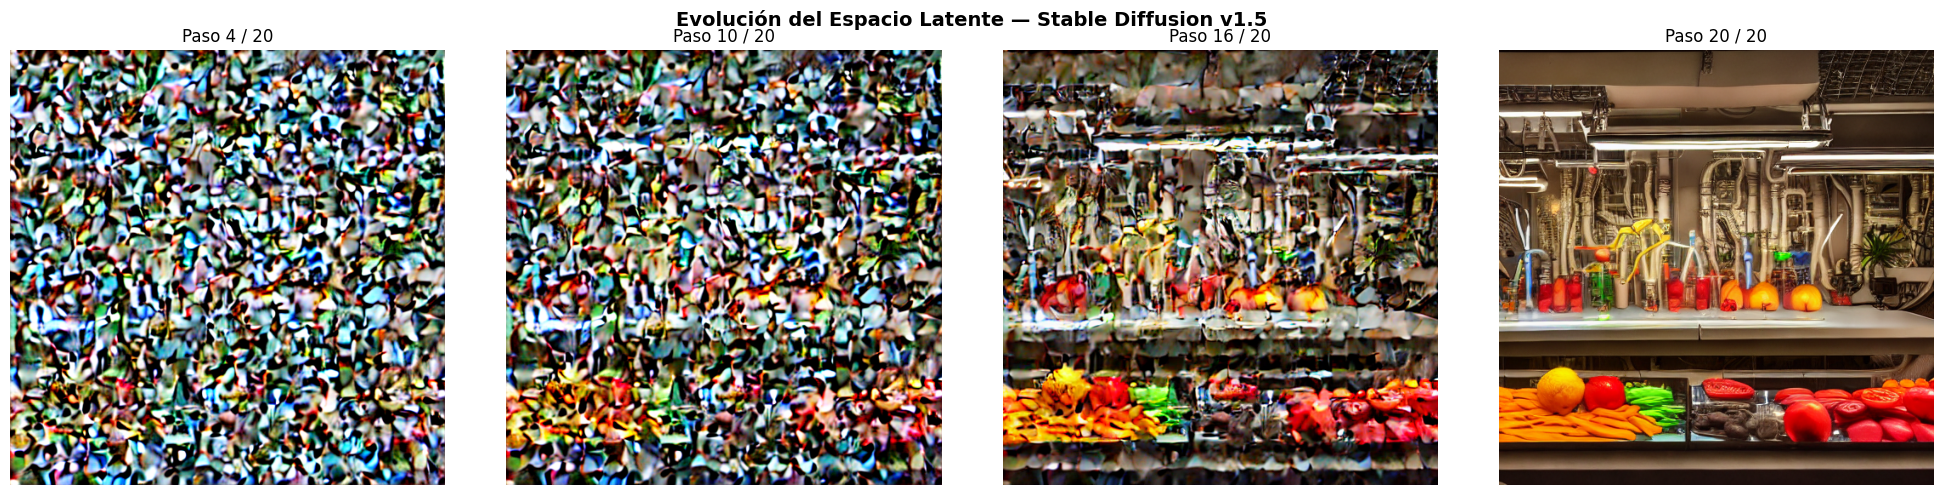

Cuadrícula guardada como latent_evolution_grid.png


In [8]:
for step, img in decoded_images.items():
    img.save(f"latent_step_{step}.png")
    print(f"Guardada: latent_step_{step}.png")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Evolución del Espacio Latente — Stable Diffusion v1.5", fontsize=14, fontweight="bold")

for idx, step in enumerate([4, 10, 16, 20]):
    axes[idx].imshow(decoded_images[step])
    axes[idx].set_title(f"Paso {step} / 20", fontsize=12)
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig("latent_evolution_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Cuadrícula guardada como latent_evolution_grid.png")

## Entrega: Análisis Teórico. Paso 4 vs Paso 16

 Pregunta del enunciado: Explicado con base en la teoría de frecuencias espaciales y Cross-Attention: ¿Qué características resuelve la U-Net en las etapas iniciales de ruido alto, y qué resuelve en las etapas finales de ruido bajo?

En primer lugar, la imagen decodificada en el paso 4 todavía se encuentra en una región de ruido alto del proceso de difusión. Por esta razón, la U-Net no está resolviendo aún detalles locales finos, sino una aproximación de bajas frecuencias espaciales: distribución general de masas, silueta amplia del objeto, zonas principales de color y composición global de la escena. En otras palabras, en esta etapa el modelo empieza a decidir “dónde” estará la fruta futurista, “qué volumen” ocupará dentro del laboratorio y cómo se separarán, de manera aproximada, las regiones luminosas y oscuras.

Además, la Cross-Attention ya introduce información semántica del prompt desde etapas tempranas. Es decir, términos como futuristic fruit, cyberpunk laboratory y neon lights comienzan a orientar la estructura latente para que la generación no sea ruido aleatorio, sino una escena coherente con el texto. Sin embargo, esa influencia todavía aparece de forma gruesa: se observan manchas de color, contornos tentativos y una composición general, pero no necesariamente detalles bien definidos.

En contraste, hacia el paso 16 el nivel de ruido es mucho menor. Por consiguiente, la U-Net puede dedicar mayor capacidad a componentes de altas frecuencias espaciales, tales como bordes más precisos, brillos intensos, texturas finas de la superficie de la fruta, reflejos del laboratorio y detalles asociados al neón. En esta fase, la imagen ya no solo necesita definir la forma global, sino corregir errores pequeños y reforzar los patrones visuales que hacen que la escena parezca cinematográfica y detallada.

Desde el punto de vista del flujo de datos, el proceso puede interpretarse así: el tensor latente inicia como ruido; luego, en cada paso, la U-Net predice el componente de ruido que debe removerse utilizando el timestep del scheduler y los embeddings textuales producidos por el encoder de texto. Posteriormente, el scheduler actualiza el latente, y finalmente el VAE decodifica ese latente hacia píxeles. Por tanto, la diferencia entre el paso 4 y el paso 16 evidencia que Stable Diffusion no construye la imagen completa de una vez, sino que primero estabiliza la composición de baja frecuencia y después refina los detalles de alta frecuencia.

En conclusión, las etapas iniciales de ruido alto resuelven principalmente forma global, composición, colores base y silueta; en cambio, las etapas finales de ruido bajo resuelven texturas finas, bordes, brillos, detalles del neón y coherencia visual local. Esta progresión confirma que la difusión latente funciona como un proceso iterativo de refinamiento: de una estructura semántica general guiada por Cross-Attention hacia una imagen final con detalles visuales cada vez más definidos.
